# **Importing Libraries**

In [ ]:
import torch
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_recall_fscore_support,classification_report,confusion_matrix,roc_curve,auc,precision_recall_curve

from transformers import AutoTokenizer,AutoModelForSequenceClassification,Trainer,TrainingArguments

# **Loading Dataset**

In [ ]:
train_path = "/content/drive/Shareddrives/NLP Task/trainV2.csv"
test_path = "/content/drive/Shareddrives/NLP Task/TestV2 - testV2.csv"

df = pd.read_csv(train_path)

label_map = {"Non-Abusive": 0, "Abusive": 1, "abusive": 1}
df["label"] = df["Class"].map(label_map)



# **Class Distribution Graph**

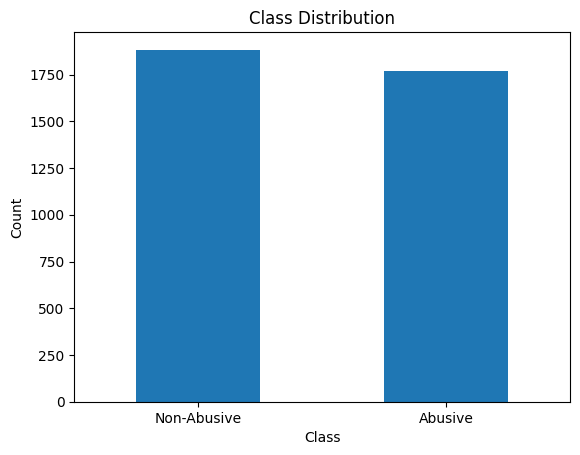

In [ ]:
plt.figure()
df["label"].value_counts().plot(kind="bar")
plt.xticks([0,1], ["Non-Abusive","Abusive"], rotation=0)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.savefig("/content/drive/Shareddrives/NLP Task/class_distribution.png")
plt.show()

# **Preprocessing**

In [ ]:
def preprocess(text):
    text = str(text)
    text = unicodedata.normalize("NFC", text)
    text = text.replace("&#39;", "'")
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"[A-Za-z]+", lambda m: m.group(0).lower(), text)
    return text

df["clean_text"] = df["Text"].apply(preprocess)

# **Train / Validation Split**

In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["clean_text"].tolist(),
    df["label"].tolist(),
    test_size=0.1,
    random_state=42,
    stratify=df["label"]
)

# **Load IndicBERT from Hugging Face**

In [ ]:
model_name = "ai4bharat/IndicBERTv2-MLM-only"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name,num_labels=2)

# Tokenization

def tokenize(texts):
    return tokenizer(texts, padding=True, truncation=True, max_length=128)

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.75M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if y

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

# **Dataset Class**

In [ ]:
class TamilDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = TamilDataset(train_encodings, train_labels)
val_dataset = TamilDataset(val_encodings, val_labels)

# **Metrics**

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:,1].numpy()

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# **Training Setup**

In [ ]:
# Training Arguments

training_args = TrainingArguments(
    output_dir="/content/drive/Shareddrives/NLP Task/indicbert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)

# Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


# **Fine Tuning**

In [ ]:
# Train
trainer.train()

# Evaluation
results = trainer.evaluate()
print(results)

# Validation Predictions
val_predictions = trainer.predict(val_dataset)

y_true = val_labels
y_pred = val_predictions.predictions.argmax(axis=1)
y_probs = torch.softmax(torch.tensor(val_predictions.predictions),dim=1)[:,1].numpy()

# Classification Report
print(classification_report(y_true,y_pred,target_names=["Non-Abusive","Abusive"]))

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.455983,0.816940,0.827381,0.785311,0.805797
2,No log,0.446736,0.792350,0.746341,0.864407,0.801047
3,0.454241,0.422914,0.822404,0.807692,0.830508,0.818942
4,0.454241,0.450845,0.836066,0.823204,0.841808,0.832402


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'eval_loss': 0.4508450925350189, 'eval_accuracy': 0.8360655737704918, 'eval_precision': 0.8232044198895028, 'eval_recall': 0.8418079096045198, 'eval_f1': 0.8324022346368715, 'eval_runtime': 3.0584, 'eval_samples_per_second': 119.67, 'eval_steps_per_second': 7.52, 'epoch': 4.0}
              precision    recall  f1-score   support

 Non-Abusive       0.85      0.83      0.84       189
     Abusive       0.82      0.84      0.83       177

    accuracy                           0.84       366
   macro avg       0.84      0.84      0.84       366
weighted avg       0.84      0.84      0.84       366



# **Confusion Matrix Heatmap**

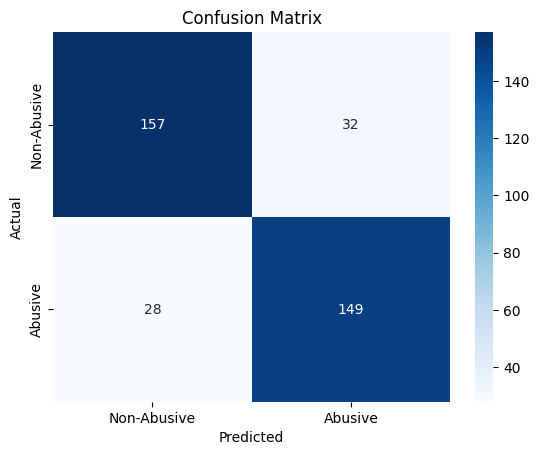

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Abusive","Abusive"],
    yticklabels=["Non-Abusive","Abusive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("/content/drive/Shareddrives/NLP Task/confusion_matrix.png")
plt.show()

# **ROC Curve**

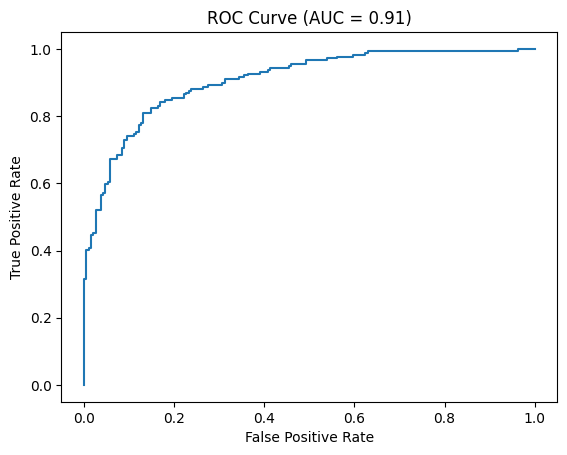

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = %.2f)" % roc_auc)
plt.savefig("/content/drive/Shareddrives/NLP Task/roc_curve.png")
plt.show()

# **Precision-Recall Curve**

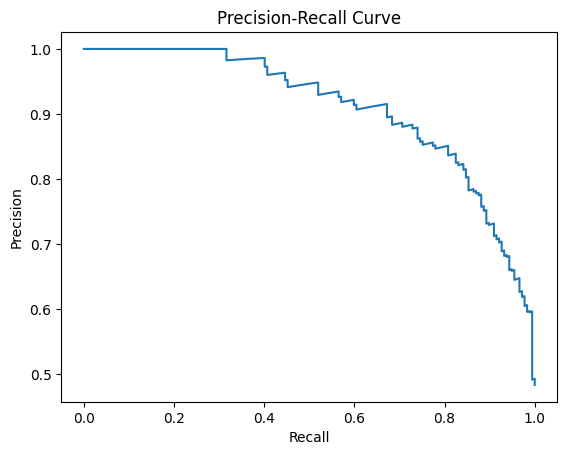

In [ ]:
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_probs)

plt.figure()
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.savefig("/content/drive/Shareddrives/NLP Task/precision_recall_curve.png")
plt.show()

# **Training & Validation Loss Graph**

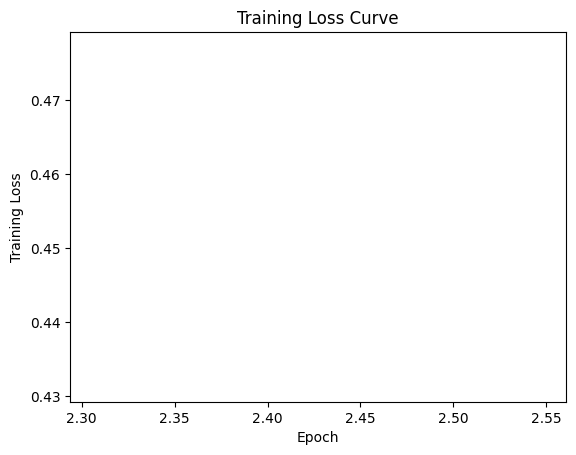

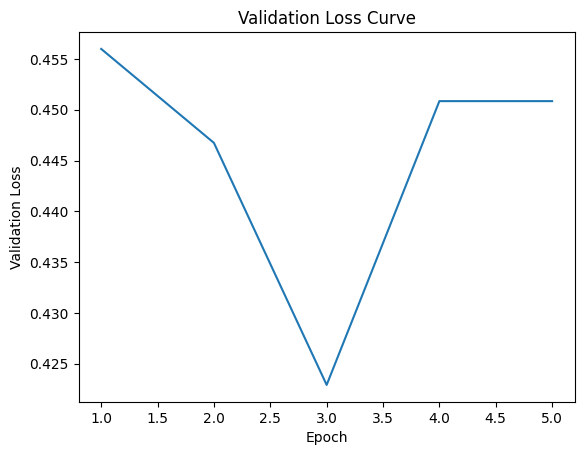

In [ ]:
logs = trainer.state.log_history

train_loss = []
eval_loss = []
epochs = []

for log in logs:
    if "loss" in log and "epoch" in log:
        train_loss.append(log["loss"])
        epochs.append(log["epoch"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])

plt.figure()
plt.plot(epochs[:len(train_loss)], train_loss)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.savefig("/content/drive/Shareddrives/NLP Task/training_loss.png")
plt.show()

plt.figure()
plt.plot(range(1,len(eval_loss)+1), eval_loss)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curve")
plt.savefig("/content/drive/Shareddrives/NLP Task/validation_loss.png")
plt.show()

# **Testing the Test Data**



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(250000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [ ]:
test_df = pd.read_csv(test_path)
test_df["clean_text"] = test_df["Text"].apply(preprocess)

test_encodings = tokenizer(
    test_df["clean_text"].tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

# Move all tensors to device
test_encodings = {k: v.to(device) for k, v in test_encodings.items()}

model.eval()
with torch.no_grad():
    outputs = model(**test_encodings)
    preds = torch.argmax(outputs.logits, dim=1).tolist()

inv_label_map = {0: "Non-Abusive", 1: "Abusive",1: "abusive"}
test_df["prediction"] = [inv_label_map[p] for p in preds]

test_df[["Text","clean_text","prediction"]].to_csv("/content/drive/Shareddrives/NLP Task/indicbert_submission.csv", index=False)

In [1]:
import json

with open("/content/drive/Shareddrives/NLP Task/notebook.ipynb") as f:
    nb = json.load(f)

if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open("clean_notebook.ipynb", "w") as f:
    json.dump(nb, f)

FileNotFoundError: [Errno 2] No such file or directory: 'notebook.ipynb'